<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# <a id='toc1_'></a>[OpenAI: Image generation Guide for Beginners](#toc0_)


Estimated time needed: **30** minutes


In this lab, you will learn how to use GPT series to generate images from text. (DALL-E has been removed)


**NOTE: Due to environment limitations, currently only the **prompt** can be modified; edit and variation features are not available at this time.**



## __Table of Contents__

<ol>
    <li><a href="#Introduction">Introduction</a></li>
    <li><a href="#What-does-this-guided-project-do?">What does this guided project do?</a></li>
    <li><a href="#Objectives">Objectives</a></li>
    <li>
        <a href="#Background">Background</a>
        <ol>
            <li><a href="#What-is-large-language-model-(LLM)?">What is large language model (LLM)?</a></li>
            <li><a href="#What-is-multimodal?">What is multimodal?</a></li>
        </ol>
    </li>
    <li>
        <a href="#Setup">Setup</a>
        <ol>
            <li><a href="#Installing-required-libraries">Installing required libraries</a></li>
        </ol>
    </li>
    <li>
        <a href="#Image-generation">Image generation</a>
        <ol>
            <li><a href="#Which-model-should-I-use?">Which model should I use?</a></li>
            <li><a href="#Generations">Generations</a></li>
        </ol>
    </li>
    <li>
        <a href="#Practice">Practice</a>
        <ol>
            <li><a href="#Use-GPT-Image-1-mini-to-generate-an-image-of-a-cat">Use GPT Image 1 Mini to generate an image of a cat</a></li>
            <li><a href="#Use-GPT-Image-2-to-generate-an-image-of-a-cat">Use GPT Image 2 to generate an image of a cat</a></li>
        </ol>
    </li>
    <li><a href="#Compare-the-two-images">Compare the two images</a></li>
    <li>
        <a href="#Exercises">Exercises</a>
        <ol>
            <li><a href="#Exercise-1:-Generate-another-image-using-GPT-Image-1-mini">Exercise 1: Generate another image using GPT Image 1 Mini</a></li>
            <li><a href="#Exercise-2:-Generate-another-image-using-GPT-Image-2">Exercise 2: Generate another image using GPT Image 2</a></li>
        </ol>
    </li>
    <li><a href="#Authors">Authors</a></li>
    <li><a href="#Contributors">Contributors</a></li>
</ol>


<h2 id="intro"><a href="#Table-of-Contents">Introduction</a></h2>


Have you ever wanted to create stunning images from just a text description? With the power of AI image generation, this is now possible. In this project, we'll explore GPT series, OpenAI's revolutionary text-to-image model that can create realistic images and art from natural language descriptions.

<h2 id="What-does-this-guided-project-do?"><a href="#Table-of-Contents">What does this guided project do?</a></h2>


This project demonstrates how to use GPT series to generate images by:
1. Crafting effective text prompts that describe the images you want to create
2. Using the OpenAI API to generate images from these prompts
3. Exploring different parameters to control the image generation process

For example, you could input a prompt like "**a serene landscape with mountains reflected in a lake at sunset**" and GPT will create a beautiful image matching your description. This technology can be used for creating illustrations, concept art, design mockups, or simply exploring your creative ideas in visual form.

<h2 id="Objectives"><a href="#Table-of-Contents">Objectives</a></h2>


After completing this lab you will be able to:
 - Craft effective prompts for GPT image generation
 - Use the OpenAI API to generate images from text descriptions
 - Understand the parameters that control image generation
 - Save and use the generated images in your projects


<h2 id="Background"><a href="#Table-of-Contents">Background</a></h2>

<h3 id="What-is-large-language-model-(LLM)?"><a href="#Table-of-Contents">What is large language model (LLM)?</a></h3>


[Large language models](https://www.ibm.com/topics/large-language-models?utm_source=skills_network&utm_content=in_lab_content_link&utm_id=Lab-DALL%C2%B7E+Image+generation+Guide+for+Beginners-v1_1741202576) are a category of foundation models trained on immense amounts of data making them capable of understanding and generating natural language and other types of content to perform a wide range of tasks.

<h3 id="What-is-multimodal?"><a href="#Table-of-Contents">What is multimodal?</a></h3>

Multimodal refers to the capability of a model to process and understand multiple types of data simultaneously. In the context of AI and machine learning, multimodal models can handle and integrate information from various modalities, such as:
 
- **Text to image**: Generating images based on textual descriptions, as seen in models like DALL·E.
- **Text to audio**: Converting written text into spoken words or sounds.
- **Image to ext**: Analyzing images to produce descriptive text or captions.
- **Audio to text**: Transcribing spoken language into written text.
- **Video analysis**: Understanding and interpreting video content by integrating visual and audio data.

This capability allows for a more comprehensive and nuanced understanding and generation of content. For example, a multimodal AI system can take a text description and generate a corresponding image or analyze an image and generate descriptive text. This integration of different types of data enables more sophisticated applications and interactions, such as creating detailed visual content from textual descriptions or providing richer context in conversational AI systems.

<h2 id="Setup"><a href="#Table-of-Contents">Setup</a></h2>


For this lab, you will be using the following libraries:

*   [`openai`](https://pypi.org/project/openai/): `openai` is a library that allows working with the OpenAI API.


<h3 id="Installing-required-libraries"><a href="#Table-of-Contents">Installing required libraries</a></h3>


The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __You must run the following cell__ to install them. Please wait until it completes.

This step could take **several minutes**, please be patient.

**NOTE**: To prevent any issues, after installing the below libraries, please restart the kernel and skip to the next cell.  You can do that by clicking the **Restart the kernel** icon.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/crvBKBOkg9aBzXZiwGEXbw/Restarting-the-Kernel.png" width="100%" alt="Restart kernel">


In [8]:
%pip install openai==2.53.0 | tail -n 1

Note: you may need to restart the kernel to use updated packages.


<h2 id="Image-generation"><a href="#Table-of-Contents">Image generation</a></h2>


The [Images API](https://platform.openai.com/docs/api-reference/images) has three endpoints with different abilities:

- **Generations**: Images from scratch, based on a text prompt
- **Edits**: Edited versions of images, where the model replaces some areas of a pre-existing image, based on a new text prompt
- **Variations**: Variations of an existing image

<h3 id="Which-model-should-I-use?"><a href="#Table-of-Contents">Which model should I use?</a></h3>


OpenAI provides multiple image‑generation models optimized for different needs: speed, cost, quality, and editing capabilities.  
This cheat sheet summarizes all major models and their options.

---

# 🟦 gpt-image-1-mini
A lightweight, fast, low‑cost model.

## Key Features
- Very fast generation  
- Lowest cost  
- Good for drafts, thumbnails, simple visuals  
- Basic prompt understanding  
- Limited detail and realism  

## Available Options
- Standard resolutions (e.g., 512×512, 1024×1024)  
- Basic variations  
- Seed control  
- Text‑to‑image generation  
- Limited image editing  

## Best For
- Rapid prototyping  
- Educational demos  
- Internal tools  
- Simple concept art  

---

# 🟩 gpt-image-1
Balanced model for general use.

## Key Features
- Better quality than mini  
- Good prompt alignment  
- Handles moderate scene complexity  
- More consistent lighting and textures  

## Available Options
- Higher resolution than mini  
- More reliable variations  
- Seed control  
- Basic inpainting/outpainting (limited)  
- Text‑to‑image + simple image editing  

## Best For
- Everyday content creation  
- Marketing drafts  
- Social media graphics  
- Medium‑detail concept art  

---

# 🟧 gpt-image-1-large
High‑quality version of gpt-image-1.

## Key Features
- Higher fidelity  
- Better text rendering  
- More accurate faces and anatomy  
- Stronger style consistency  

## Available Options
- High‑resolution output  
- Stronger variations  
- Better inpainting/outpainting  
- More advanced prompt control  
- Image + text input for edits  

## Best For
- Professional content creation  
- Detailed illustrations  
- Product mockups  
- Cinematic concept art  

---

# 🟩 gpt-image-2 (Flagship Model)
The highest‑quality OpenAI image model.

## Key Features
- Photorealistic output  
- Excellent prompt alignment  
- Handles complex scenes, reflections, shadows  
- Accurate text inside images  
- Best face/anatomy rendering  
- Advanced multimodal reasoning  

## Available Options
- High‑resolution generation  
- Advanced editing tools:
  - Inpainting  
  - Outpainting  
  - Region‑based editing  
  - Mask‑based editing  
  - Prompt‑based refinement  
- Image + text input  
- High‑quality variations  
- Seed control  
- Strong safety/content filtering  

## Best For
- Production‑quality images  
- Marketing & design  
- Storytelling & cinematic visuals  
- Detailed concept art  
- Professional creative workflows  

---

# 🔥 Quick Comparison Table

| Feature / Option | gpt-image-1-mini | gpt-image-1 | gpt-image-1-large | gpt-image-2 |
|------------------|------------------|-------------|-------------------|-------------|
| Speed | Very fast | Fast | Medium | Slower |
| Cost | Very low | Low | Medium | Higher |
| Quality | Moderate | Good | High | Photorealistic |
| Scene Complexity | Low | Medium | High | Very high |
| Text Rendering | Weak | Moderate | Strong | Excellent |
| Faces/Anatomy | Basic | Better | Strong | Best |
| Variations | Basic | Good | Strong | Excellent |
| Inpainting/Outpainting | Minimal | Limited | Good | Advanced |
| Image + Text Editing | Limited | Moderate | Strong | Full support |
| Best Use Case | Drafts | General use | Professional art | Production-quality |

---

# ⭐ Summary
- **gpt-image-1-mini** → Fast, cheap, simple image generation.  
- **gpt-image-1** → Balanced model for everyday use.  
- **gpt-image-1-large** → High-quality, strong editing, professional visuals.  
- **gpt-image-2** → Flagship model with photorealism and advanced editing.


<h3 id="Generations"><a href="#Table-of-Contents">Generations</a></h3>


The [image generations](https://platform.openai.com/docs/api-reference/images/create) endpoint allows you to create an original image with a text prompt. Each image can be returned either as a URL or Base64 data, using the [response_format](https://platform.openai.com/docs/api-reference/images/create#images/create-response_format) parameter. The default output is URL, and each URL expires after an hour.

<h2 id="Practice"><a href="#Table-of-Contents">Practice</a></h2>


<h3 id="Use-GPT-Image-1-mini-to-generate-an-image-of-a-cat"><a href="#Table-of-Contents">Use GPT Image 1 Mini to generate an image of a cat</a></h3>



Please use the following prompt: "a white siamese cat"


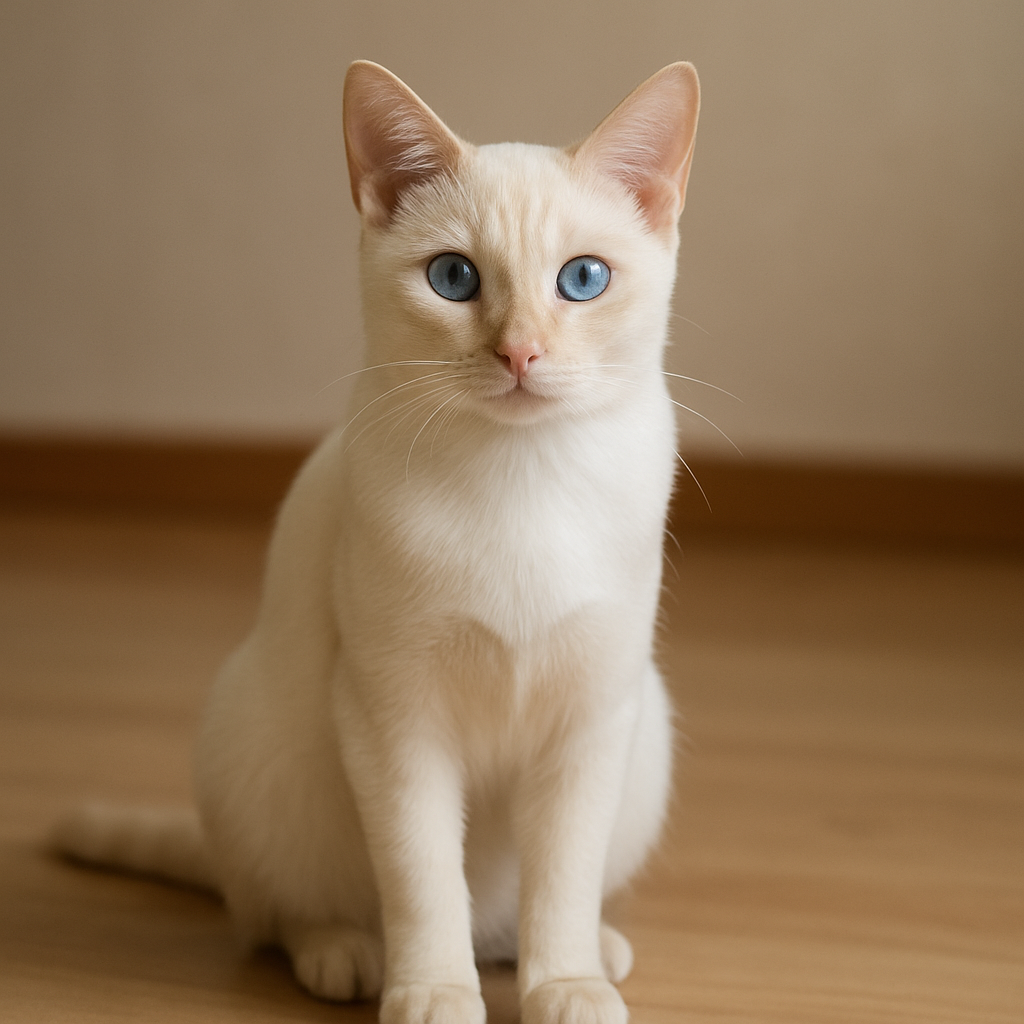

In [5]:
from openai import OpenAI
from IPython import display
import base64

client = OpenAI()

response = client.images.generate(
    model="gpt-image-1-mini",
    prompt="a white siamese cat",
    size="1024x1024",
    # quality="standard",
    n=1,
)

b64_image = response.data[0].b64_json
image_data = base64.b64decode(b64_image, validate=True)

with open("siamese_cat.png", "wb") as f:
    f.write(image_data)

display.Image(data="siamese_cat.png", width=512)

<h3 id="Use-GPT-Image-2-to-generate-an-image-of-a-cat"><a href="#Table-of-Contents">Use GPT Image 2 to generate an image of a cat</a></h3>



Please use the same prompt: "a white siamese cat"


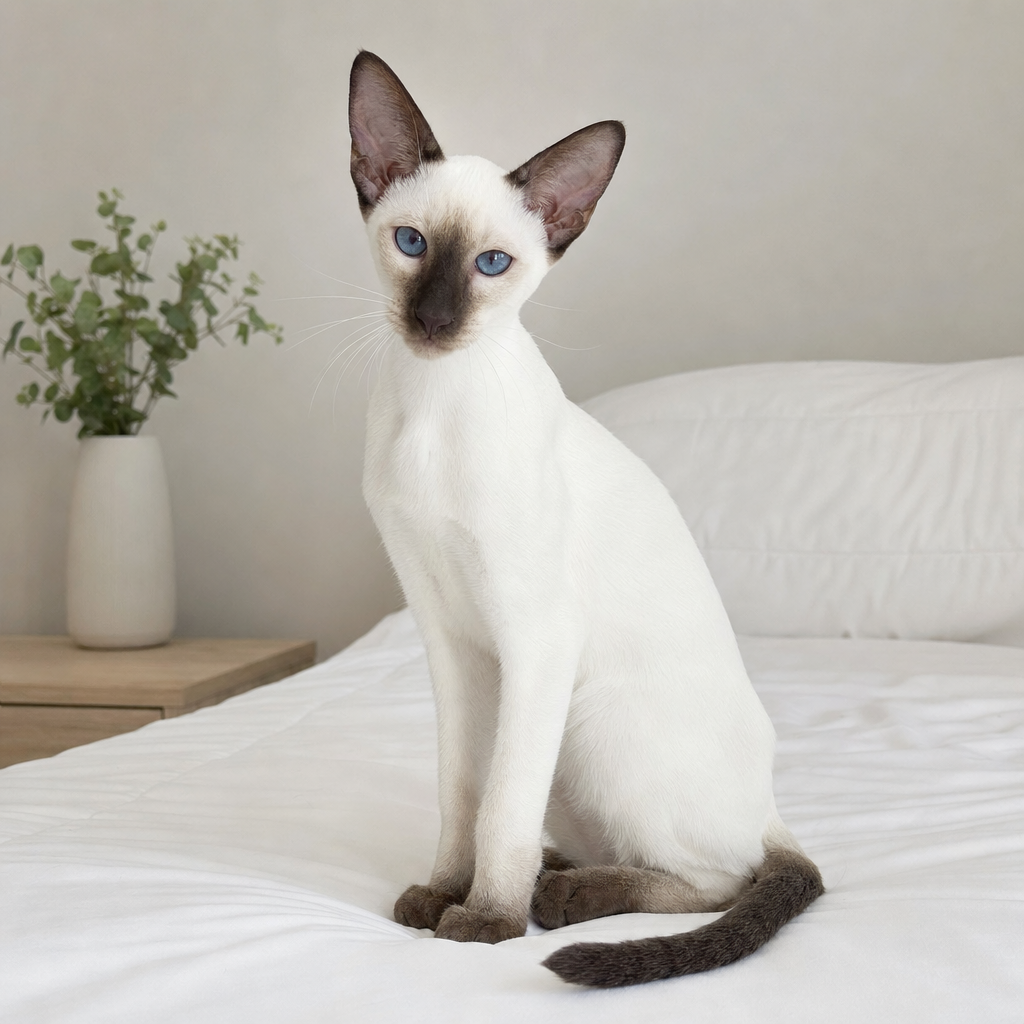

In [7]:
from openai import OpenAI
from IPython import display

client = OpenAI()

response = client.images.generate(
    model="gpt-image-2",
    prompt="a white siamese cat",
    size="1024x1024",
    quality="high",
    n=1,
)

b64_image = response.data[0].b64_json
image_data = base64.b64decode(b64_image, validate=True)

with open("siamese_cat2.png", "wb") as f:
    f.write(image_data)

display.Image(data="siamese_cat2.png", width=512)

<h2 id="Compare-the-two-images"><a href="#Table-of-Contents">Compare the two images</a></h2>


Which one is better?


<h2 id="Exercises"><a href="#Table-of-Contents">Exercises</a></h2>

<h3 id="Exercise-1:-Generate-another-image-using-GPT-Image-1-mini"><a href="#Table-of-Contents">Exercise 1: Generate another image using GPT Image 1 mini</a></h3>


Please generate another image using GPT Image 1 mini.

Please use the following prompt: "a beautiful lake with a sunset"


In [ ]:
exercise_prompt = "a beautiful lake with a sunset"
response = client.images.generate(
    model="gpt-image-1-mini",
    prompt=exercise_prompt,
    size="1024x1024",
    # quality="standard",
    n=1,
)

b64_image = response.data[0].b64_json
image_data = base64.b64decode(b64_image, validate=True)

with open("exercise1.png", "wb") as f:
    f.write(image_data)

display.Image(data="exercise1.png", width=512)

<details>
    <summary>Click to show solution</summary>

```python
from openai import OpenAI
from IPython import display

client = OpenAI()

response = client.images.generate(
    model="dall-e-2",
    prompt="a beautiful lake with a sunset",
    size="1024x1024",
    n=1,
)

url = response.data[0].url
display.Image(url=url, width=512)
```
</details>


<h3 id="Exercise-2:-Generate-another-image-using-GPT-Image-2"><a href="#Table-of-Contents">Exercise 2: Generate another image using GPT Image 2</a></h3>


Please generate another image using GPT Image 2.

Please use the following prompt: "a beautiful lake with a sunset"


In [ ]:
response = client.images.generate(
    model="gpt-image-2",
    prompt=exercise_prompt,
    size="1024x1024",
    # quality="standard",
    n=1,
)

b64_image = response.data[0].b64_json
image_data = base64.b64decode(b64_image, validate=True)

with open("exercise2.png", "wb") as f:
    f.write(image_data)

display.Image(data="exercise2.png", width=512)

<details>
    <summary>Click here for Solution
    </summary>

```python
from openai import OpenAI
from IPython import display

client = OpenAI()

response = client.images.generate(
    model="dall-e-3",
    prompt="a beautiful lake with a sunset",
    size="1024x1024",
    quality="standard",
    n=1,
)

url = response.data[0].url
display.Image(url=url, width=512)
```
</details>


<h2 id="Authors"><a href="#Table-of-Contents">Authors</a></h2>


[Ricky Shi](https://author.skills.network/instructors/ricky_shi)
[Hailey Quach](https://author.skills.network/instructors/hailey_quach)


<h2 id="Contributors"><a href="#Table-of-Contents">Contributors</a></h2>

[Karan Goswami](https://author.skills.network/instructors/karan_goswami)

```{Change Log}
```
```{|Date (YYYY-MM-DD)|Version|Changed By|Change Description||-|-|-|-||2025-02-26|1.0|Ricky Shi|Create project|
```



Copyright © IBM Corporation. All rights reserved.
